# Customize and Train a Neural Network with PyTorch
In most ML tasks, we need to build our own neural networks (NN). [PyTorch](https://pytorch.org/) provides building blocks for a large variety of NNs -- just like Lego pieces!

In this Lab, we will build a basic feedforward NN (FNN) for prediction tasks.

In Google Colab, you do not need to install `PyTorch`. On your own device, you will need to install it via
```bash
pip install torch
```

In [ ]:
import torch
import torch.nn as nn # the nn module in torch contains functions and classes for neural networks
from torch import optim # optim provides optimization modules to optimize the NN parameters
from matplotlib import pyplot as plt

## 1. A Vanilla Case
We will show a minimal implementation of neural network first.

### We synthesize the features and labels

Note that both input (X) and output (y) should be a 2D matrix.

The rows are the data, and the columns are the features.

For prediction, y is of shape (n_data, 1).



X shape: torch.Size([2000, 1])
y shape: torch.Size([2000, 1])


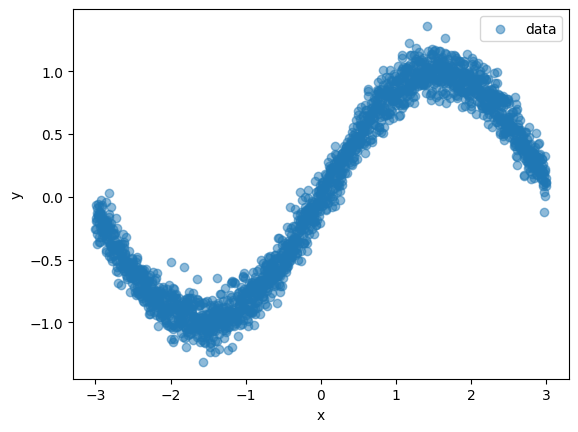

In [ ]:
torch.manual_seed(0) # again you can set random seeds for reproduction

x = torch.linspace(-3, 3, 2000).reshape(2000, 1) # remember feature data are always 2D matrix with (num_data, num_feature), here we only have one feature
y = torch.sin(x) + 0.1 * torch.randn_like(x)
print("X shape:", x.shape)
print("y shape:", y.shape)
# let's have a look
plt.scatter(x, y, alpha=0.5, zorder=0, label="data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

### Let's define a minimal FNN
We use `torch.nn.Sequential()` to put all layers together.

In [ ]:
model = nn.Sequential(
    nn.Linear(1, 32), # feature dimension is 1, hidden layer has 32 neurons
    nn.ReLU(), # activation
    nn.Linear(32, 1) # hidden to output, output is still dimension 1
)

# the model will take x and output y

In [1]:
# we didn't initialize W&B, they are randomly generated with uniform distribution
# Let's have a look!
# for name, param in model.named_parameters():
#     print(f"{name}:")
#     print(param)
#     print()

### Your Task:
Look up how to assign weights and bias to an FNN.

### Define the loss function and optimizer
We use Adam optimizer, a very popular method for gradient descent.

In [ ]:
loss_fn = nn.MSELoss() # MSE loss
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # lr is the learning rate

In [ ]:
# Training loop
n_epoch = 1000
for epoch in range(n_epoch):
    optimizer.zero_grad() # PyTorch accumulates gradients by default, so we need to clear gradients from the previous step.
    y_hat = model(x) # forward pass
    loss = loss_fn(y_hat, y) # evaluate loss
    loss.backward() # evaluate gradient with backpropagation
    optimizer.step() # this will update model.parameters()
    if (epoch+1) % 100 == 0 or epoch==0: # print progress every 100 steps
        print(f"Epoch {epoch+1} | Loss = {loss.item()}")


Epoch 1 | Loss = 0.025312261655926704
Epoch 100 | Loss = 0.021327625960111618
Epoch 200 | Loss = 0.018496932461857796
Epoch 300 | Loss = 0.016419868916273117
Epoch 400 | Loss = 0.01488810870796442
Epoch 500 | Loss = 0.013811781071126461
Epoch 600 | Loss = 0.013040904887020588
Epoch 700 | Loss = 0.012498431839048862
Epoch 800 | Loss = 0.01212372537702322
Epoch 900 | Loss = 0.011845888569951057
Epoch 1000 | Loss = 0.011625022627413273


### Your Turn: Play with the learning rate.
Note that you need to restart from defining the model, otherwise you are training on top of the previous steps.

In [ ]:
# Prediction
model.eval()  # set model to evaluation mode
with torch.no_grad(): # turn off evaluating the gradient so it is faster
    x_test = torch.tensor([[-1.0], [0.0], [1.0]])
    y_pred = model(x_test)
    print(y_pred)


tensor([[-0.8337],
        [-0.0039],
        [ 0.8629]])


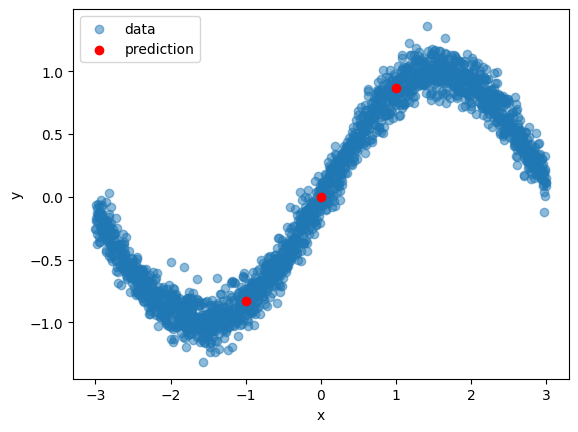

In [ ]:
# visualize
plt.scatter(x, y, alpha=0.5, zorder=0, label="data")
plt.scatter(x_test, y_pred, c="r", label="prediction")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()


## 2. Define a Class

We will put all the elements in one class.

**Tips:**

When naming a class or a function, use complicated naming strategy, so you won't accidentally overwrite some exisiting functions.

E.g., instead of naming your class as `Linear`, you can name it `SimpleLinearFn`.



In [ ]:
class SineApproximator(nn.Module): # This is standard: we inherit nn.Module class
    def __init__(self, input_dim=1, hidden_dim=32, output_dim=1):
        super().__init__() # super() is the parent class

        # define the FNN model
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    # forward passing
    # You MUST define a forward function
    def forward(self, x):
        return self.model(x)

    # do not use the name train(), because nn.Module.train() is a built-in function that sets the mode to the train mode.
    def train_model(self, x_train, y_train, n_epoch=1000, lr=1e-3):
        # loss function and optimizer
        loss_fn = nn.MSELoss()
        optimizer = optim.Adam(self.parameters(), lr=lr)

        for epoch in range(n_epoch):
            optimizer.zero_grad()        # clear previous gradients
            y_hat = self(x_train)        # forward pass, equivalent to self.forward(x_train), this syntax is preferred in pytorch
            loss = loss_fn(y_hat, y_train)
            loss.backward()              # backpropagation
            optimizer.step()             # update parameters

            if (epoch+1) % 100 == 0 or epoch == 0:
                print(f"Epoch {epoch+1} | Loss = {loss.item():.6f}")

    def predict(self, x_test):
        self.eval()                      # evaluation mode
        with torch.no_grad():            # disable gradient computation
            return self(x_test)


### Now Let's use the class to do the training!

In [ ]:
# Create dataset
x = torch.linspace(-3, 3, 2000).reshape(-1, 1)      # (num_data, num_features)
y = torch.sin(x) + 0.1 * torch.randn_like(x)       # noisy sine wave

# Initialize model
my_model = SineApproximator()

# Train model
my_model.train_model(x, y, n_epoch=1000, lr=1e-3)

Epoch 1 | Loss = 1.727627
Epoch 100 | Loss = 0.194933
Epoch 200 | Loss = 0.151982
Epoch 300 | Loss = 0.121528
Epoch 400 | Loss = 0.093275
Epoch 500 | Loss = 0.067898
Epoch 600 | Loss = 0.047215
Epoch 700 | Loss = 0.032761
Epoch 800 | Loss = 0.024082
Epoch 900 | Loss = 0.019305
Epoch 1000 | Loss = 0.016578


In [ ]:
# Make predictions
x_test = torch.tensor([[-1.0], [0.0], [1.0]])
y_pred = my_model.predict(x_test)
print(y_pred)

tensor([[-0.8782],
        [ 0.0066],
        [ 0.8660]])


### Let's change the feature dimension

In [ ]:
# Create dataset
N_data = 2000
x1 = torch.linspace(-3, 3, N_data)
x2 = torch.linspace(0, 2, N_data)
X = torch.stack([x1, x2], dim=1)   # dim=1 makes sure that the two arrays are stacked column-wise, shape: (N_data, 2)
y = torch.sin(x1) + 0.5 * x2**2

y = y + 0.1 * torch.randn_like(y) # add noise
print("Not supported output shape:", y.shape)
y = y.reshape(-1, 1) # add another dimenion to make the shape: (2000, 1)
print("Supported output shape:", y.shape)


Not supported output shape: torch.Size([2000])
Supported output shape: torch.Size([2000, 1])


In [ ]:

# Initialize model
my_model = SineApproximator(input_dim=2) # now we have a different input dimension

# Train model
my_model.train_model(X, y, n_epoch=1000, lr=1e-3)

Epoch 1 | Loss = 2.220277
Epoch 100 | Loss = 0.302745
Epoch 200 | Loss = 0.132103
Epoch 300 | Loss = 0.072612
Epoch 400 | Loss = 0.052986
Epoch 500 | Loss = 0.044023
Epoch 600 | Loss = 0.038348
Epoch 700 | Loss = 0.033980
Epoch 800 | Loss = 0.030233
Epoch 900 | Loss = 0.026875
Epoch 1000 | Loss = 0.023832


# Play with the hyperparameters of the model.